In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')
from src.utils.config import PROCESSED_DIR

In [ ]:
# Feature matrix
df = pd.read_csv(PROCESSED_DIR / 'features/AAPL_features.csv',
                 index_col=0, parse_dates=True)
print(f'Feature matrix shape: {df.shape}')
print(f'Columns: {len(df.columns)} total')
print(f'Missing values: {df.isnull().sum().sum()}')
print(df[['Close','RSI_14','MACD','ATR_14','OBV']].tail(5))

Feature matrix shape: (2508, 47)
Columns: 47 total
Missing values: 0
                 Close     RSI_14      MACD    ATR_14         OBV
Date                                                             
2025-12-16  274.353271  50.175182  2.320893  4.911728  8050327600
2025-12-17  271.585876  45.186591  1.730635  4.883445  8000188900
2025-12-18  271.935547  45.918256  1.276353  5.011323  8051819600
2025-12-19  273.414185  49.017353  1.023843  4.988773  8196451600
2025-12-22  270.716675  44.057280  0.599154  4.872921  8159879800


In [ ]:
# Splits 
X_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_train.csv',
                      index_col=0, parse_dates=True)
X_val   = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_val.csv',
                      index_col=0, parse_dates=True)
X_test  = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/X_test.csv',
                      index_col=0, parse_dates=True)
print(f'\nTrain: {len(X_train)} rows | Val: {len(X_val)} rows | Test: {len(X_test)} rows')
print(f'Train ends:  {X_train.index.max()}')
print(f'Val starts:  {X_val.index.min()}')
print(f'Test starts: {X_test.index.min()}')


Train: 1762 rows | Val: 124 rows | Test: 622 rows
Train ends:  2022-12-30 00:00:00
Val starts:  2023-01-03 00:00:00
Test starts: 2023-07-03 00:00:00


In [4]:
# Target balance 
y_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/y_train.csv',
                      index_col=0)
print(f'\nClass balance (train):')
print(y_train['Target_Direction'].value_counts(normalize=True))
# Should be roughly 50/50 — markets go up and down roughly equally


Class balance (train):
Target_Direction
1    0.588536
0    0.411464
Name: proportion, dtype: float64


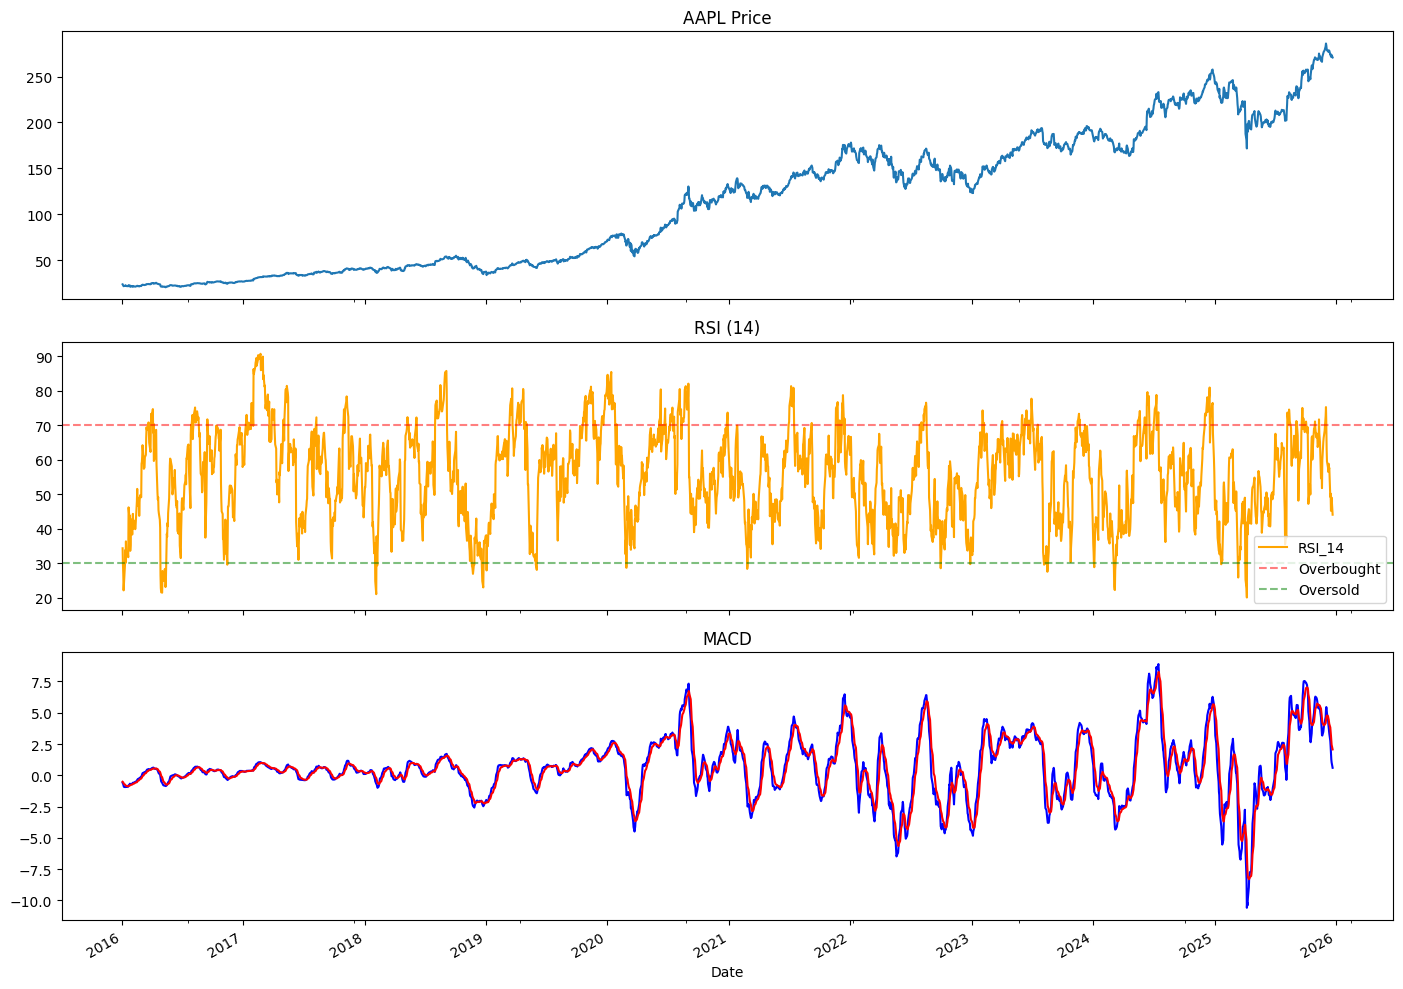

Feature verification complete!


In [5]:
#  Plot RSI and price together 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df['Close'].plot(ax=ax1, title='AAPL Price')
df['RSI_14'].plot(ax=ax2, title='RSI (14)', color='orange')
ax2.axhline(70, color='red',   linestyle='--', alpha=0.5, label='Overbought')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
ax2.legend()
df['MACD'].plot(ax=ax3, title='MACD', color='blue')
df['MACD_Signal'].plot(ax=ax3, color='red')
plt.tight_layout()
plt.savefig('../../docs/feature_check.png')
plt.show()
print('Feature verification complete!')


In [ ]:
y_train = pd.read_csv(PROCESSED_DIR / 'splits/AAPL/y_train.csv', index_col=0)
counts = y_train['Target_Direction'].value_counts()
ratio  = counts[1] / counts[0]
print(f'Up days:   {counts[1]} ({counts[1]/len(y_train)*100:.1f}%)')
print(f'Down days: {counts[0]} ({counts[0]/len(y_train)*100:.1f}%)')
print(f'Ratio: {ratio:.2f}')


Up days:   1037 (58.9%)
Down days: 725 (41.1%)
Ratio: 1.43


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
def get_class_weights(y_train):
    """Compute class weights to handle imbalance."""
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train
    )
    weight_dict = dict(zip(classes, weights))
    print(f'Class weights: {weight_dict}')
    # Example output: {0: 1.1, 1: 0.9}
    # We pass this to XGBoost and PyTorch models
    return weight_dict